In [1]:
# baixa o repositório na máquina do colab, pra permitir o import de
# módulos do repositório
!rm -fr /content/deep-learning-pa1
!git clone https://github.com/nicolasspaniol/deep-learning-pa1.git

# adiciona o caminho do repositório clonado no path
import sys
sys.path.insert(0,'/content/deep-learning-pa1/src')

Cloning into 'deep-learning-pa1'...
remote: Enumerating objects: 200, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 200 (delta 19), reused 9 (delta 9), pack-reused 159 (from 1)
Receiving objects: 100% (200/200), 5.51 MiB | 12.46 MiB/s, done.
Resolving deltas: 100% (81/81), done.


In [2]:
# local files
import utils
from synthetic_dataset import SyntheticEllipseDataset
from resunet import ResUNet
from bbbc038_dataset import BBBC038Dataset

import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device.type

'cpu'

In [5]:
# Carregando os dados: BBBC038
# Verifica se a pasta já não existe antes de baixar

if not os.path.exists('./data/stage1_train'):
    !wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip -P ./data
    !cd data && unzip -q stage1_train.zip -d stage1_train
    !rm ./data/stage1_train.zip

if not os.path.exists('./data/stage1_test'):
    !wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_test.zip -P ./data
    !cd data && unzip -q stage1_test.zip -d stage1_test
    !rm ./data/stage1_test.zip

--2026-09-12 01:26:13--  https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip
Resolving data.broadinstitute.org (data.broadinstitute.org)... 69.173.68.137
Connecting to data.broadinstitute.org (data.broadinstitute.org)|69.173.68.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82923446 (79M) [application/zip]
Saving to: ‘./data/stage1_train.zip’

stage1_train.zip    100%[===================>]  79.08M  51.5MB/s    in 1.5s    

2026-09-12 01:26:14 (51.5 MB/s) - ‘./data/stage1_train.zip’ saved [82923446/82923446]

--2026-09-12 01:26:17--  https://data.broadinstitute.org/bbbc/BBBC038/stage1_test.zip
Resolving data.broadinstitute.org (data.broadinstitute.org)... 69.173.68.137
Connecting to data.broadinstitute.org (data.broadinstitute.org)|69.173.68.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9545388 (9.1M) [application/zip]
Saving to: ‘./data/stage1_test.zip’

stage1_test.zip     100%[===================>]   9.10M  29.5

In [6]:
class CenterOffsetDataset(Dataset):
    """
    Wraps/extends a BBBC038Dataset (Trilha C) to additionally produce:
      - heatmap:      (1, H, W) gaussian blob peaked at each instance center
      - offsets:      (2, H, W) dx, dy from each foreground pixel to its
                       instance's center
      - offset_mask:  (1, H, W) 1 on foreground pixels, 0 elsewhere (mask the
                       offset loss with this)

    Does not touch BBBC038Dataset at all -- just consumes its output.
    """

    def __init__(self, base_dataset, gaussian_sigma: float = 4.0):
        assert base_dataset.is_training, "CenterOffsetDataset needs the training split (needs instance_map)"
        self.base_dataset = base_dataset
        self.gaussian_sigma = gaussian_sigma

        img_size = base_dataset.img_size
        yy, xx = torch.meshgrid(
            torch.arange(img_size, dtype=torch.float32),
            torch.arange(img_size, dtype=torch.float32),
            indexing='ij',
        )
        self._yy = yy
        self._xx = xx

    def __len__(self):
        return len(self.base_dataset)

    def _build_center_targets(self, instance_map: torch.Tensor, alpha: float = 2.0, eps: float = 1e-2):
        H, W = instance_map.shape
        heatmap = torch.zeros((H, W), dtype=torch.float32)
        offsets = torch.zeros((2, H, W), dtype=torch.float32)
        offset_mask = torch.zeros((H, W), dtype=torch.float32)

        instance_ids = torch.unique(instance_map)
        instance_ids = instance_ids[instance_ids > 0]

        for inst_id in instance_ids.tolist():
            inst_mask = instance_map == inst_id
            ys, xs = torch.nonzero(inst_mask, as_tuple=True)
            if ys.numel() == 0:
                continue

            cy = ys.float().mean()
            cx = xs.float().mean()

            # matriz de covariância dos pixels da instância (encaixa a gaussiana na forma/orientação do objeto)
            dx = xs.float() - cx
            dy = ys.float() - cy
            n = xs.numel()

            var_x = (dx * dx).sum() / n + eps
            var_y = (dy * dy).sum() / n + eps
            cov_xy = (dx * dy).sum() / n

            cov = torch.tensor([[var_x, cov_xy], [cov_xy, var_y]])
            cov_scaled = alpha * cov  # escala pra controlar o "espalhamento" da gaussiana
            cov_inv = torch.linalg.inv(cov_scaled)

            # distância de Mahalanobis de cada pixel da imagem ao centro, usando a covariância da instância
            dxx = self._xx - cx
            dyy = self._yy - cy
            mdist_sq = (
                cov_inv[0, 0] * dxx ** 2
                + 2 * cov_inv[0, 1] * dxx * dyy
                + cov_inv[1, 1] * dyy ** 2
            )
            blob = torch.exp(-0.5 * mdist_sq)
            heatmap = torch.maximum(heatmap, blob)

            offsets[0][inst_mask] = cx - self._xx[inst_mask]
            offsets[1][inst_mask] = cy - self._yy[inst_mask]
            offset_mask[inst_mask] = 1.0

        return heatmap.unsqueeze(0), offsets, offset_mask.unsqueeze(0)

    def __getitem__(self, idx):
        sample_id, image, semantic_mask, instance_map = self.base_dataset[idx]
        heatmap, offsets, offset_mask = self._build_center_targets(instance_map)

        return sample_id, image, heatmap, offsets, offset_mask

In [7]:
# carrega o dataset

dataset = CenterOffsetDataset(BBBC038Dataset(True, './data/stage1_train'))
train_dataset, val_dataset = random_split(dataset, [0.8, 0.2])
test_dataset = BBBC038Dataset(False, './data/stage1_test')

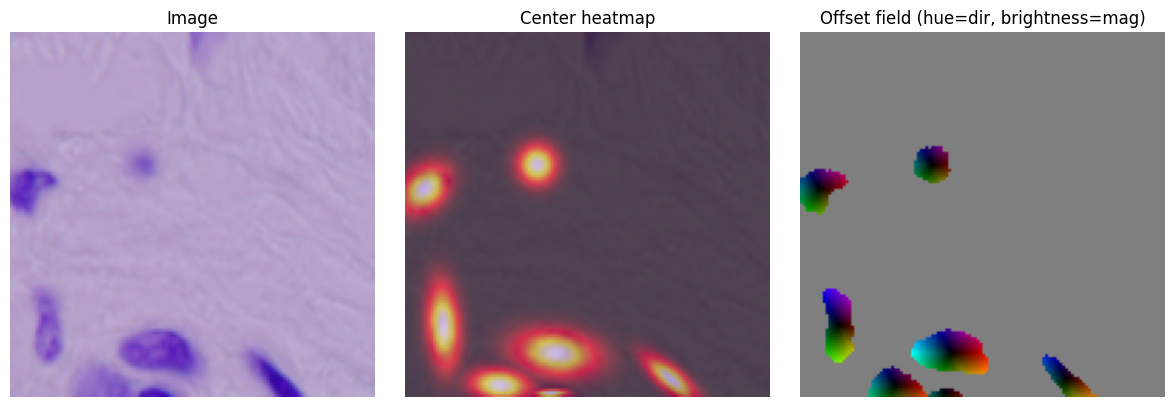

In [8]:
# visualizando uma amostra do dataset

import matplotlib.colors as mcolors

def offsets_to_rgb(dx, dy, mask):
    angle = np.arctan2(dy, dx)
    hue = (angle + np.pi) / (2 * np.pi)
    mag = np.sqrt(dx ** 2 + dy ** 2)
    mag_max = mag.max() if mag.max() > 0 else 1.0
    value = np.clip(mag / mag_max, 0, 1)
    hsv = np.stack([hue, np.ones_like(hue), value], axis=-1)
    rgb = mcolors.hsv_to_rgb(hsv)
    rgb[mask == 0] = 0.5
    return rgb

def plot_sample(sample):
    sample_id, image, heatmap, offsets, offset_mask = sample
    img_np = image.permute(1, 2, 0).numpy()
    heatmap_np = heatmap[0].numpy()
    dx, dy = offsets[0].numpy(), offsets[1].numpy()
    mask_np = offset_mask[0].numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img_np); axes[0].set_title("Image"); axes[0].axis('off')
    axes[1].imshow(img_np); axes[1].imshow(heatmap_np, cmap='hot', alpha=0.6); axes[1].set_title("Center heatmap"); axes[1].axis('off')
    axes[2].imshow(offsets_to_rgb(dx, dy, mask_np)); axes[2].set_title("Offset field (hue=dir, brightness=mag)"); axes[2].axis('off')

    plt.tight_layout()
    plt.show()

plot_sample(dataset[4])

In [13]:
# cria o modelo

model = ResUNet(3, 3).to(device)
model.load_state_dict(torch.load('instance_weights', map_location=device, weights_only=True))
model.eval()

ResUNet(
  (enc0): ResUNetEncoderBlock(
    (seq): Sequential(
      (0): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (1): ReLU()
      (2): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4): ReLU()
      (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (shortcut): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (enc1): ResUNetEncoderBlock(
    (seq): Sequential(
      (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (1): ReLU()
      (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4): ReLU()
      (5): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (shortcut): Conv2d(64, 128, kernel_size=(1, 1), stri

In [41]:
# treinando o modelo

loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

heatmap_loss_fn = nn.MSELoss()
offset_loss_fn = nn.L1Loss(reduction='none')  # 'none' pra poder mascarar pixel a pixel

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
offset_loss_weight = 1  # ajustem esse peso conforme a escala relativa das perdas

model.train()
for epoch in range(25):
    for batch, (_, image, heatmap, offsets, offset_mask) in enumerate(loader):
        image = image.to(device)
        heatmap = heatmap.to(device)
        offsets = offsets.to(device)
        offset_mask = offset_mask.to(device)

        pred = model(image)  # espera-se (B, 3, H, W): canal 0 = heatmap, canais 1:3 = offsets
        pred_heatmap = pred[:, 0:1]
        pred_offsets = pred[:, 1:3]

        loss_heatmap = heatmap_loss_fn(pred_heatmap, heatmap)

        # L1 nos offsets, só nos pixels de foreground (offset_mask expandido pros 2 canais)
        raw_offset_loss = offset_loss_fn(pred_offsets, offsets)
        mask_2ch = offset_mask.expand_as(raw_offset_loss)
        loss_offsets = (raw_offset_loss * mask_2ch).sum() / mask_2ch.sum().clamp(min=1.0)

        loss = loss_heatmap + offset_loss_weight * loss_offsets

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        print(f'{epoch}/{batch} - loss={loss.item():.4f} (heatmap={loss_heatmap.item():.4f}, offsets={loss_offsets.item():.4f})')

0/0 - loss=2.4082 (heatmap=0.0369, offsets=2.3714)
0/1 - loss=2.5045 (heatmap=0.0353, offsets=2.4691)
0/2 - loss=1.6853 (heatmap=0.0389, offsets=1.6464)
0/3 - loss=1.3973 (heatmap=0.0284, offsets=1.3689)
0/4 - loss=2.9653 (heatmap=0.0395, offsets=2.9258)
0/5 - loss=2.3870 (heatmap=0.0315, offsets=2.3555)
0/6 - loss=1.5367 (heatmap=0.0306, offsets=1.5061)
0/7 - loss=1.8623 (heatmap=0.0323, offsets=1.8301)
0/8 - loss=1.4486 (heatmap=0.0367, offsets=1.4119)
0/9 - loss=1.8668 (heatmap=0.0198, offsets=1.8470)
0/10 - loss=1.6922 (heatmap=0.0227, offsets=1.6694)
0/11 - loss=1.7405 (heatmap=0.0371, offsets=1.7035)
0/12 - loss=1.7646 (heatmap=0.0308, offsets=1.7338)
0/13 - loss=1.6695 (heatmap=0.0274, offsets=1.6421)
0/14 - loss=1.7373 (heatmap=0.0219, offsets=1.7154)
0/15 - loss=2.1305 (heatmap=0.0208, offsets=2.1097)
0/16 - loss=2.7350 (heatmap=0.0445, offsets=2.6905)
0/17 - loss=2.8371 (heatmap=0.0206, offsets=2.8164)
0/18 - loss=1.6267 (heatmap=0.0257, offsets=1.6010)
0/19 - loss=1.2963 (he

KeyboardInterrupt: 

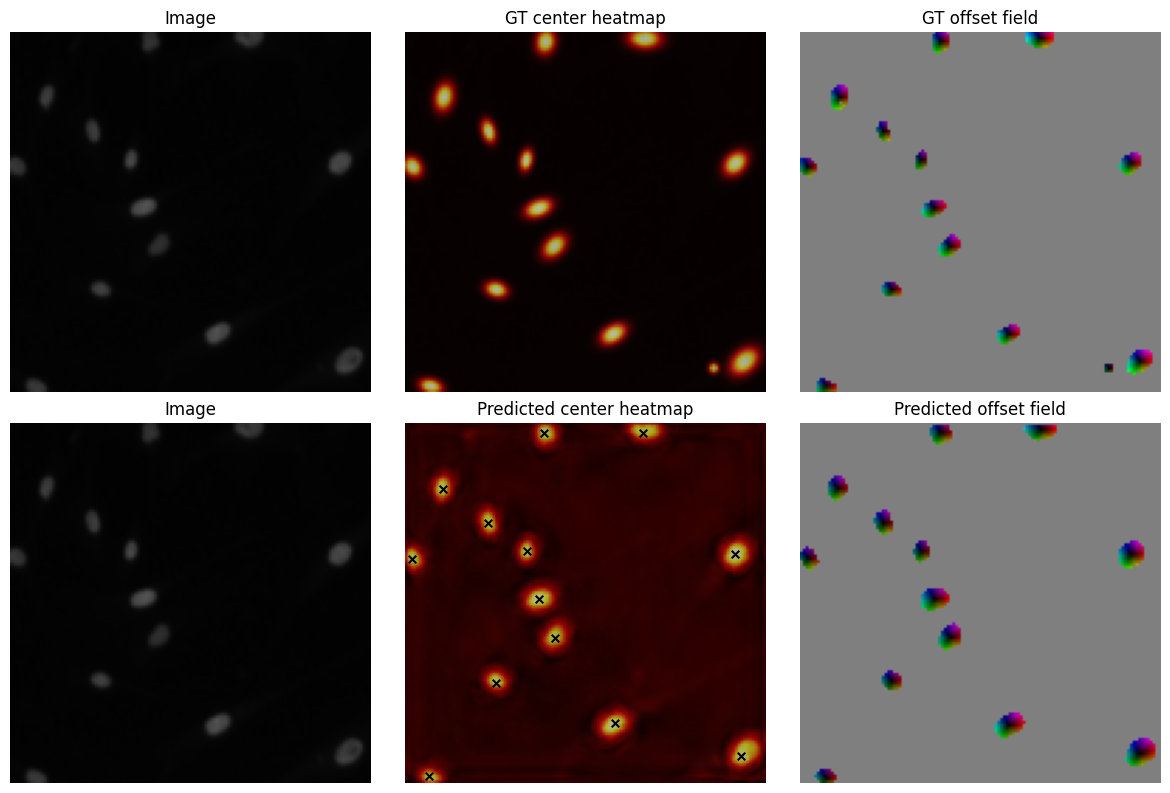

In [39]:
# visualizando a predição do modelo numa amostra

def find_peaks(heatmap_np, threshold=0.3, nms_kernel=5, top_k=50):
    """
    Detecta picos locais num heatmap 2D usando NMS via max-pooling.
    nms_kernel: tamanho da janela (ímpar) -> define a distância mínima entre picos.
    """
    hm = torch.from_numpy(heatmap_np).float().unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

    pad = nms_kernel // 2
    hm_max = F.max_pool2d(hm, kernel_size=nms_kernel, stride=1, padding=pad)

    # só mantém pixels que são o próprio máximo local
    keep = (hm_max == hm).float()
    peaks = hm * keep

    peaks = peaks[0, 0].numpy()
    ys, xs = np.where(peaks > threshold)
    scores = peaks[ys, xs]

    # ordena por score e pega os top_k
    order = np.argsort(-scores)[:top_k]
    return xs[order], ys[order]

@torch.no_grad()
def plot_prediction(model, sample, device):
    model.eval()
    sample_id, image, heatmap, offsets, offset_mask = sample

    image_batch = image.unsqueeze(0).to(device)
    pred = model(image_batch).cpu()[0]  # (3, H, W)

    pred_heatmap = pred[0].numpy()
    pred_dx, pred_dy = pred[1].numpy(), pred[2].numpy()

    # máscara de foreground previsto: threshold no próprio heatmap previsto
    pred_mask = (pred_heatmap > 0.3).astype(np.float32)

    img_np = image.permute(1, 2, 0).numpy()
    gt_heatmap_np = heatmap[0].numpy()
    gt_dx, gt_dy = offsets[0].numpy(), offsets[1].numpy()
    gt_mask_np = offset_mask[0].numpy()

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    # linha de cima: ground truth
    axes[0, 0].imshow(img_np); axes[0, 0].set_title("Image"); axes[0, 0].axis('off')
    axes[0, 1].imshow(img_np); axes[0, 1].imshow(gt_heatmap_np, cmap='hot', alpha=0.6)
    axes[0, 1].set_title("GT center heatmap"); axes[0, 1].axis('off')
    axes[0, 2].imshow(offsets_to_rgb(gt_dx, gt_dy, gt_mask_np))
    axes[0, 2].set_title("GT offset field"); axes[0, 2].axis('off')

    # linha de baixo: predição do modelo
    axes[1, 0].imshow(img_np); axes[1, 0].set_title("Image"); axes[1, 0].axis('off')
    axes[1, 1].imshow(img_np); axes[1, 1].imshow(pred_heatmap, cmap='hot', alpha=0.6)
    axes[1, 1].set_title("Predicted center heatmap"); axes[1, 1].axis('off')
    axes[1, 2].imshow(offsets_to_rgb(pred_dx, pred_dy, pred_mask))
    axes[1, 2].set_title("Predicted offset field"); axes[1, 2].axis('off')

    # detecta picos
    pred_xs, pred_ys = find_peaks(pred_heatmap)
    axes[1, 1].scatter(pred_xs, pred_ys, s=30, c='k', marker='x')

    plt.tight_layout()
    plt.show()

plot_prediction(model, val_dataset[random.randint(0, 50)], device)

In [116]:
# salva os pesos do modelo

torch.save(model.state_dict(), 'instance_weights')

In [ ]:
# hiperparâmetros pra validar:
# - treshold do heatmap (pra mascara e centroides)
# - nms_kernel

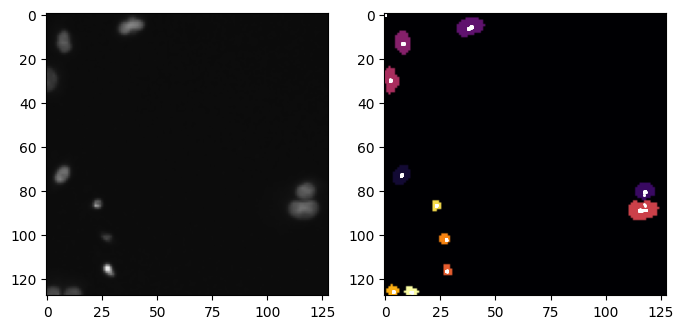

In [177]:
def assign_instances(positions, centroids, background_mask=None):
    """
    positions: (2, H, W) float tensor - predicted (x, y) or (row, col) per pixel
    centroids: (N, 2) tensor/array of centroid coordinates, same convention as positions
    background_mask: optional (H, W) bool tensor - True where pixel should be instance 0
                      (e.g. low-confidence pixels you zeroed out)

    returns: (H, W) long tensor of instance ids, 1..N (0 = background)
    """
    centroids = torch.as_tensor(centroids, dtype=torch.float32)  # (N, 2)
    H, W = positions.shape[1:]

    # flatten pixel positions to (H*W, 2)
    pix = positions.permute(1, 2, 0).reshape(-1, 2)  # (H*W, 2)

    # pairwise distances (H*W, N)
    dists = torch.cdist(pix, centroids)  # euclidean (norm 2) by default

    nearest = dists.argmin(dim=1) + 1  # +1 so instance ids start at 1, 0 reserved for bg
    instances = nearest.reshape(H, W)

    if background_mask is not None:
        instances[background_mask] = 0

    return instances

model.eval()
sample_id, image, heatmap, offsets, offset_mask = val_dataset[22]
image_batch = image.unsqueeze(0).to(device)
pred = model(image_batch).cpu()[0].detach()
xs, ys = find_peaks(pred[0].numpy(), threshold=0.3, nms_kernel=5, top_k=50)

centroids = np.stack([ys, xs], axis=1)  # (N, 2) as (row, col) to match positions

bg_mask = pred[0] < 0.3  # same threshold you used to zero out positions
positions = torch.stack(torch.meshgrid(
    torch.arange(128, dtype=torch.float32),
    torch.arange(128, dtype=torch.float32),
    indexing='ij'
))
positions[0] += pred[2]
positions[1] += pred[1]
instances = assign_instances(positions, centroids, background_mask=bg_mask)
positions[:,pred[0] < .3] = 0

tx = positions[0].flatten().numpy()
ty = positions[1].flatten().numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image.permute(1, 2, 0))
axes[1].imshow(instances, cmap='inferno')
axes[1].scatter(ty, tx, s=1, c='white')
plt.show()